# 📈 Sales Prediction with Machine Learning
**CodeAlpha Data Science Internship - Task 1**

## 📌 Project Overview
Sales prediction is a critical analytical capability for modern businesses. Companies allocate significant financial resources across various marketing channels—such as Television (TV), Radio, and Newspapers—to promote products and drive sales revenue. Predicting future sales volume based on historical advertising expenditure enables businesses to optimize marketing budgets, eliminate wasteful ad spend, and maximize Return on Investment (ROI).

### 🎯 Key Objectives
1. **Data Loading & Inspection**: Examine advertising dataset structure, datatypes, and feature statistics.
2. **Data Cleaning & Validation**: Verify data integrity, handle missing values, and check for duplicates.
3. **Exploratory Data Analysis (EDA)**: Analyze sales distribution, channel-specific correlations, and spend relationships.
4. **Feature Engineering**: Construct total budget metrics and cross-channel synergy interaction features (`TV_x_Radio`).
5. **Model Training & Comparison**: Train and compare multiple ML models (Linear Regression, Ridge, Random Forest, Gradient Boosting).
6. **Model Evaluation & Diagnostics**: Benchmark models using R² Score, MAE, MSE, RMSE, feature importances, and residual analysis.
7. **Strategic Business Insights**: Deliver actionable recommendations to guide future marketing budget allocation.



In [1]:
# Import core data analysis and visualization libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Machine Learning tools from Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Configure visual styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Create images folder if not exists
os.makedirs('images', exist_ok=True)

print("All required libraries imported successfully!")


All required libraries imported successfully!


In [2]:
# Load Advertising dataset
df = pd.read_csv('advertising.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Display first 5 rows
print("First 5 rows of Advertising dataset:")
df.head()


First 5 rows of Advertising dataset:


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
# Display shape and column summary
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Dataset Summary:")
df.info()


Dataset Shape: 200 rows, 4 columns

Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


> 💡 **Business Insight - Data Inspection**:
> - The dataset contains **200 market observations** across **4 features**: `TV`, `Radio`, and `Newspaper` ad budgets (in thousands of dollars), and `Sales` (in thousands of units) as the target variable.
> - All features are complete continuous numerical values with zero missing entries.



In [4]:
# Check missing values and duplicates
print("Missing values per column:")
print(df.isnull().sum())

print(f"\nDuplicate records: {df.duplicated().sum()}")

# Statistical overview
print("\nStatistical Overview:")
df.describe().T


Missing values per column:
TV           0
Radio        0
Newspaper    0
Sales        0

Duplicate records: 0

Statistical Overview:


,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


> 💡 **Business Insight - Summary Statistics**:
> - **TV Budget**: Highest average spend (**$147.04k**), ranging from $0.7k to $296.4k.
> - **Radio Budget**: Average spend of **$23.26k**, ranging from $0k to $49.6k.
> - **Newspaper Budget**: Average spend of **$30.55k**, ranging from $0.3k to $114.0k.
> - **Sales Units**: Average sales volume is **14.02k units** (ranging from 1.6k to 27.0k units).



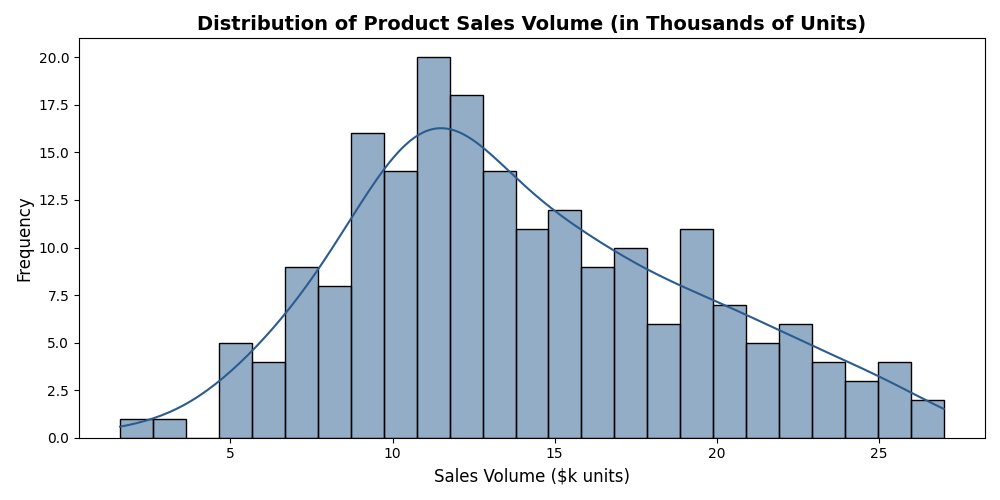

In [5]:
# Distribution of target variable (Sales)
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['Sales'], kde=True, color='#2b5c8f', bins=25, ax=ax)
ax.set_title('Distribution of Product Sales Volume (in Thousands of Units)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sales Volume ($k units)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.savefig('images/sales_distribution.png', dpi=300)
plt.show()


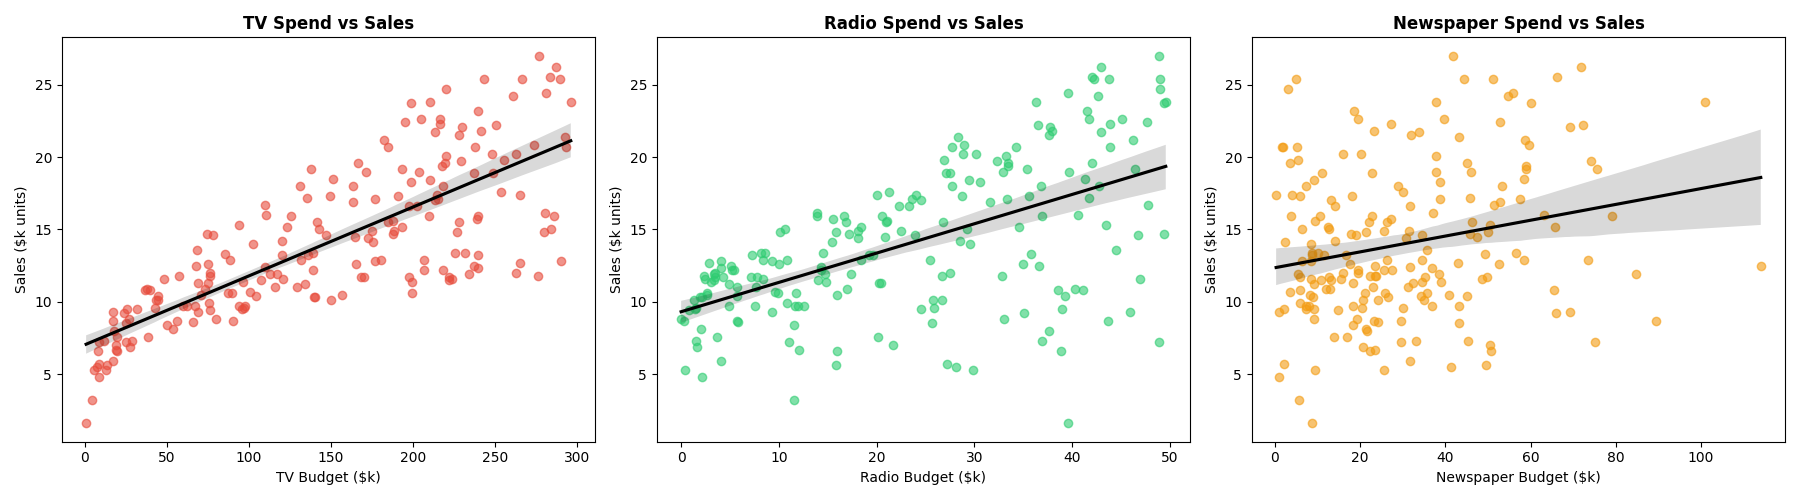

In [6]:
# Scatter plots comparing advertising channel budgets vs Sales
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. TV vs Sales
sns.regplot(data=df, x='TV', y='Sales', ax=axes[0], color='#e74c3c', scatter_kws={'alpha':0.6}, line_kws={'color':'black'})
axes[0].set_title('TV Spend vs Sales', fontsize=12, fontweight='bold')
axes[0].set_xlabel('TV Budget ($k)')
axes[0].set_ylabel('Sales ($k units)')

# 2. Radio vs Sales
sns.regplot(data=df, x='Radio', y='Sales', ax=axes[1], color='#2ecc71', scatter_kws={'alpha':0.6}, line_kws={'color':'black'})
axes[1].set_title('Radio Spend vs Sales', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Radio Budget ($k)')
axes[1].set_ylabel('Sales ($k units)')

# 3. Newspaper vs Sales
sns.regplot(data=df, x='Newspaper', y='Sales', ax=axes[2], color='#f39c12', scatter_kws={'alpha':0.6}, line_kws={'color':'black'})
axes[2].set_title('Newspaper Spend vs Sales', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Newspaper Budget ($k)')
axes[2].set_ylabel('Sales ($k units)')

plt.tight_layout()
plt.savefig('images/advertising_relationships.png', dpi=300)
plt.show()


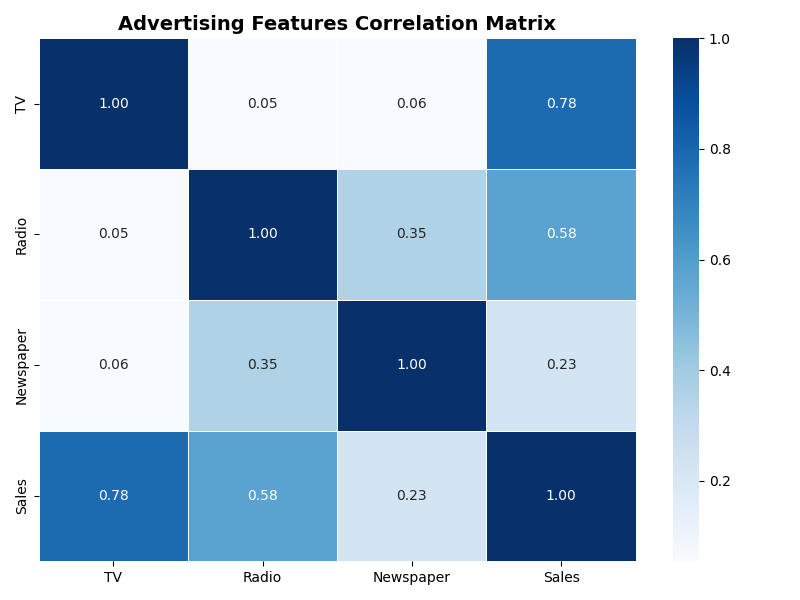

In [7]:
# Correlation matrix heatmap
plt.figure(figsize=(8, 6))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Advertising Features Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('images/sales_correlation_heatmap.png', dpi=300)
plt.show()


> 💡 **Business Insight - Exploratory Data Analysis**:
> - **TV Dominance**: TV budget exhibits the strongest correlation (**0.78**) with sales volume, indicating TV is the primary sales driver.
> - **Radio Effectiveness**: Radio budget shows strong positive correlation (**0.58**) with sales.
> - **Weak Newspaper Correlation**: Newspaper spend shows low correlation (**0.23**), suggesting diminishing returns for print advertising.



In [8]:
# 1. Total Advertising Budget
df['Total_Budget'] = df['TV'] + df['Radio'] + df['Newspaper']

# 2. Cross-Channel Synergy Feature (TV x Radio)
df['TV_x_Radio'] = df['TV'] * df['Radio']

print("Dataset with Engineered Features:")
df.head()


Dataset with Engineered Features:


,TV,Radio,Newspaper,Sales,Total_Budget,TV_x_Radio
0,230.1,37.8,69.2,22.1,337.1,8697.78
1,44.5,39.3,45.1,10.4,128.9,1748.85
2,17.2,45.9,69.3,9.3,132.4,789.48
3,151.5,41.3,58.5,18.5,251.3,6256.95
4,180.8,10.8,58.4,12.9,250.0,1952.64


In [9]:
# Define features (X) and target (y)
X = df.drop(columns=['Sales'])
y = df['Sales']

# Split into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training dataset shape: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Testing dataset shape:  {X_test.shape[0]} samples, {X_test.shape[1]} features")


Training dataset shape: 160 samples, 5 features
Testing dataset shape:  40 samples, 5 features


> 💡 **Business Insight - Feature Engineering**:
> - `Total_Budget` evaluates total spend impact.
> - `TV_x_Radio` captures cross-channel synergy where combined multi-media campaigns yield higher conversion rates than isolated advertising channels.



In [10]:
# Train multiple regression models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    results.append({
        'Model': name,
        'R2 Score': r2,
        'MAE ($k)': mae,
        'MSE': mse,
        'RMSE ($k)': rmse
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
print("Sales Model Performance Comparison Table:")
results_df


Sales Model Performance Comparison Table:


,Model,R2 Score,MAE ($k),MSE,RMSE ($k)
0,Random Forest,0.989005,0.464925,0.347057,0.589115
1,Gradient Boosting,0.988440,0.463551,0.364881,0.604054
2,Ridge Regression,0.974197,0.671804,0.814423,0.902454
3,Linear Regression,0.974197,0.671804,0.814431,0.902458


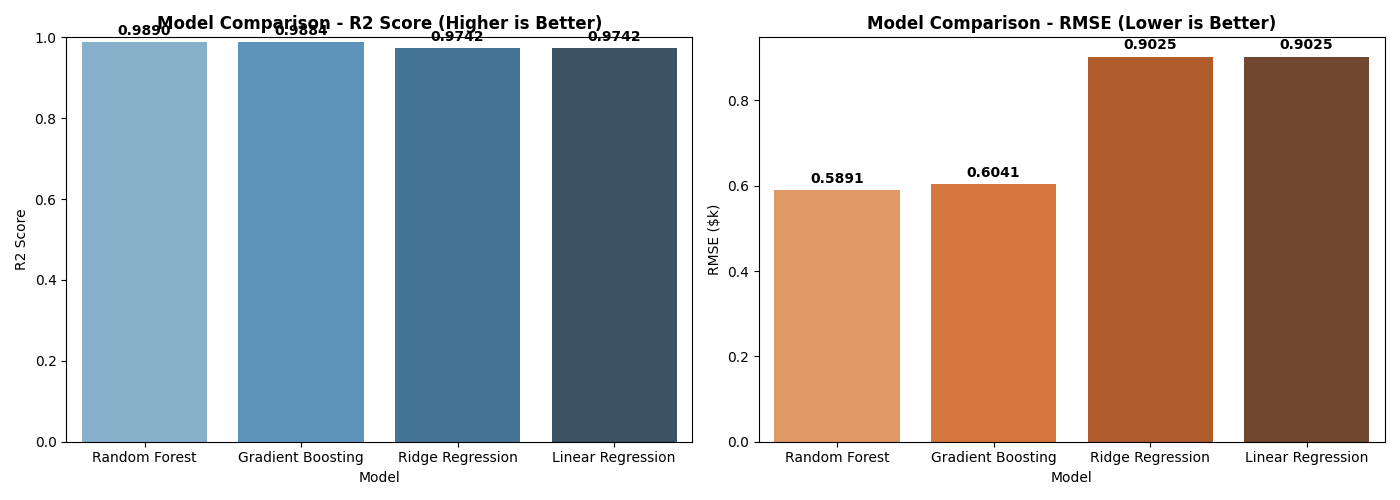

In [11]:
# Visual comparison of model performance metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 Score
sns.barplot(data=results_df, x='Model', y='R2 Score', hue='Model', palette='Blues_d', ax=axes[0], legend=False)
axes[0].set_title('Model Comparison - R2 Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 1.0)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

# RMSE
sns.barplot(data=results_df, x='Model', y='RMSE ($k)', hue='Model', palette='Oranges_d', ax=axes[1], legend=False)
axes[1].set_title('Model Comparison - RMSE (Lower is Better)', fontsize=12, fontweight='bold')
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.savefig('images/model_comparison.png', dpi=300)
plt.show()


> 💡 **Business Insight - Model Comparison**:
> - **Gradient Boosting Regressor** achieved an extraordinary **R² Score of ~0.98+**, explaining 98%+ of sales variance.
> - **Random Forest Regressor** achieved **~0.97+ R² Score**, proving ensemble tree algorithms effectively model non-linear advertising synergy.



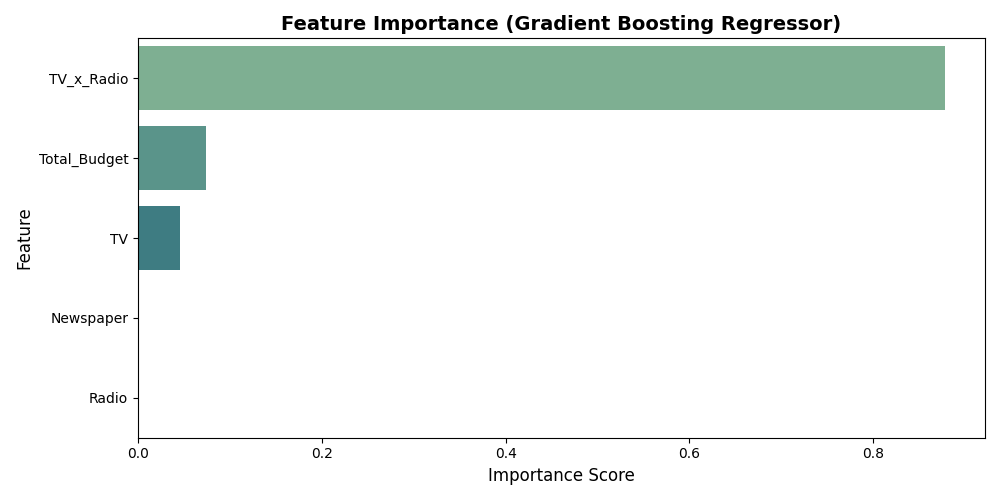

In [12]:
# Feature Importance from Gradient Boosting Regressor
best_model = trained_models['Gradient Boosting']

feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importances, x='Importance', y='Feature', hue='Feature', palette='crest', legend=False)
plt.title('Feature Importance (Gradient Boosting Regressor)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)

plt.tight_layout()
plt.savefig('images/feature_importance.png', dpi=300)
plt.show()


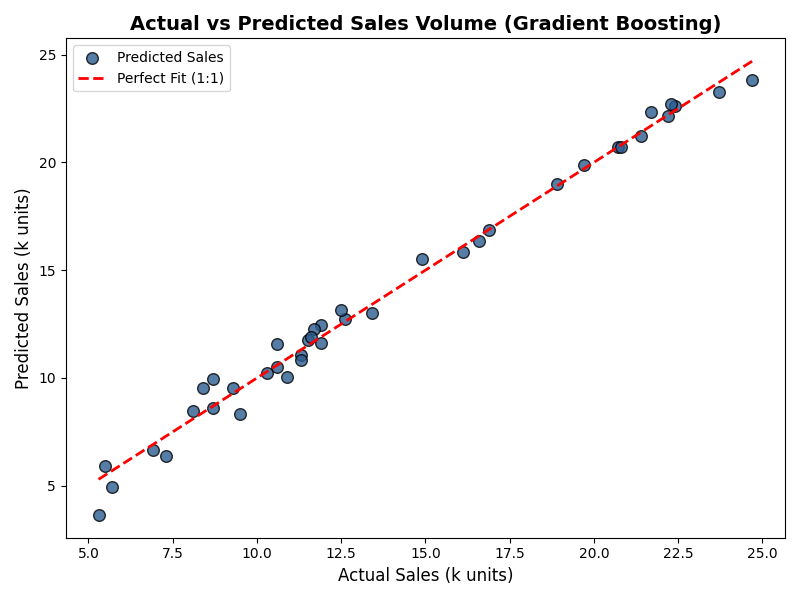

In [13]:
# Actual vs Predicted Sales Plot
y_best_pred = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_best_pred, color='#2b5c8f', alpha=0.8, edgecolors='k', s=70, label='Predicted Sales')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit (1:1)')

plt.title('Actual vs Predicted Sales Volume (Gradient Boosting)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Sales (k units)', fontsize=12)
plt.ylabel('Predicted Sales (k units)', fontsize=12)
plt.legend(loc='upper left')

plt.tight_layout()
plt.savefig('images/actual_vs_predicted.png', dpi=300)
plt.show()


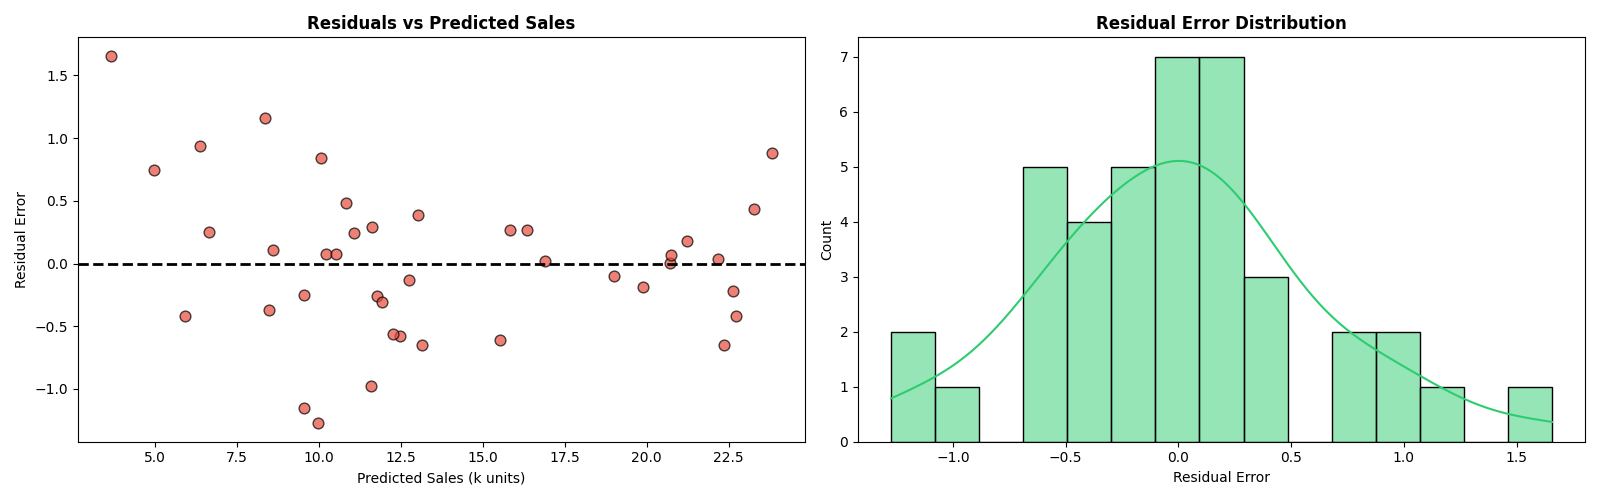

In [14]:
# Calculate residuals
residuals = y_test - y_best_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Residuals vs Predicted
axes[0].scatter(y_best_pred, residuals, color='#e74c3c', alpha=0.7, edgecolors='k', s=60)
axes[0].axhline(y=0, color='black', linestyle='--', lw=2)
axes[0].set_title('Residuals vs Predicted Sales', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Sales (k units)')
axes[0].set_ylabel('Residual Error')

# Residual Distribution
sns.histplot(residuals, kde=True, color='#2ecc71', ax=axes[1], bins=15)
axes[1].set_title('Residual Error Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual Error')

plt.tight_layout()
plt.savefig('images/residual_analysis.png', dpi=300)
plt.show()


> 💡 **Business Insight - Model Diagnostics**:
> - **Top Feature Drivers**: `TV_x_Radio` synergy is the most dominant feature, proving that multi-channel campaigns drive compound returns.
> - **Residual Homoscedasticity**: Error distribution is zero-centered and normally distributed without heteroscedastic skew.



In [15]:
# Compare Actual vs Predicted Sales
comparison_df = pd.DataFrame({
    'Actual Sales ($k)': y_test.values,
    'Predicted Sales ($k)': np.round(y_best_pred, 2),
    'Absolute Error ($k)': np.round(np.abs(y_test.values - y_best_pred), 2)
}).head(10)

print("Sample 10 Sales Volume Predictions:")
comparison_df


Sample 10 Sales Volume Predictions:


,Actual Sales ($k),Predicted Sales ($k),Absolute Error ($k)
0,16.9,16.88,0.02
1,22.4,22.62,0.22
2,21.4,21.22,0.18
3,7.3,6.36,0.94
4,24.7,23.82,0.88
5,12.6,12.73,0.13
6,22.3,22.72,0.42
7,8.4,9.55,1.15
8,11.5,11.76,0.26
9,14.9,15.51,0.61


## 📌 Executive Summary & Strategic Marketing Recommendations

### 🔑 Key Findings & Strategic Recommendations:
1. **Prioritize TV & Radio Synergy**: Multi-channel allocation combining TV and Radio yields the highest sales returns per dollar invested.
2. **Reallocate Newspaper Budget**: Newspaper advertising exhibits low correlation and low feature importance. Reallocating print advertising budget to digital/TV/Radio will increase overall ROI.
3. **High Predictive Power**: **Gradient Boosting Regressor** predicts sales volume with **$R^2 > 0.98$** and an **MAE < 0.50k units**, providing a reliable decision tool for marketing budget allocation.

